In [20]:
import sys,os
sys.path.append("../../src")
from quspin.operators import hamiltonian,quantum_operator
from quspin.basis import spin_basis_1d
from quspin_functions import projector_string as Pn
from quspin_functions import TFIM 
from common_imports import *
import numpy.linalg as la
from numpy import vdot 

In [27]:

L = 4
basis = spin_basis_1d(L,pauli=-1)

gs = np.linspace(0.01,0,10)
ns = np.arange(1,L+1)




In [22]:
Ps = [Pn(ni,"x",basis) for ni in ns]


In [23]:
groundstates=[]
for g in tqdm(gs):
    H = TFIM(basis)
    params = dict(H0=1,g=g)
    H0 = (H.tohamiltonian(params).todense())
    E0,V0 = la.eigh(H0)
    V0 = array(V0)
    psi0 = V0[:,0]

    groundstates.append(psi0)

100%|██████████| 10/10 [00:00<00:00, 508.44it/s]


In [29]:
Data = []

for g in groundstates:
    expt = [ np.vdot(g,P@g) for P in Ps]
    Data.append(expt)

Data=array(Data)

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_5322/3302901083.py:4: RuntimeWarning: divide by zero encountered in matmul
  expt = [ np.vdot(g,P@g) for P in Ps]
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_5322/3302901083.py:4: RuntimeWarning: overflow encountered in matmul
  expt = [ np.vdot(g,P@g) for P in Ps]
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_5322/3302901083.py:4: RuntimeWarning: invalid value encountered in matmul
  expt = [ np.vdot(g,P@g) for P in Ps]


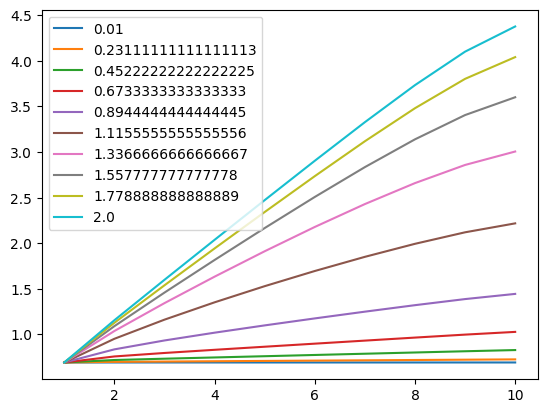

In [30]:
plot(ns,-log(Data.T),label=gs)

legend()